# AV2 — Teoria da Computabilidade
**Equipe:** João Pedro Silva da Silva · Rodrigo Marques Matos da Silva · Noam Geraldo Ismael Coelho · Analice Alves Johnston Pinheiro
**Modelos:** 4 — Máquina de Turing Não Determinística · 7 — λ-Cálculo  
**Professor:** Daniel Leal Souza · Semestre 01/2026

---
## Seção 1 — Imports e Utilitários

In [1]:
import copy
from collections import deque
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set
from enum import Enum
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [2]:
class Direction(Enum):
    LEFT  = 'L'
    RIGHT = 'R'
    STAY  = 'S'

Transition    = Tuple[str, str, Direction]
TransitionMap = Dict[Tuple[str, str], List[Transition]]

In [3]:
@dataclass
class Configuration:
    state  : str
    tape   : List[str]
    head   : int
    step   : int = 0
    history: List['Configuration'] = field(default_factory=list, repr=False)

    def __hash__(self):
        return hash((self.state, tuple(self.tape), self.head))

    def __eq__(self, other):
        return (self.state == other.state
                and self.tape == other.tape
                and self.head == other.head)

    def tape_repr(self) -> str:
        parts = [f"[{s}]" if i == self.head else f" {s} "
                 for i, s in enumerate(self.tape)]
        return "".join(parts).rstrip()

    def short_repr(self) -> str:
        return (f"Passo {self.step:>3} | "
                f"Estado: {self.state:<24} | "
                f"Cab:{self.head:>2} | "
                f"Fita: {self.tape_repr()}")

In [4]:
def print_trace(history: List[Configuration], accepted: bool, entrada: str) -> None:
    verdict = "ACEITA ✅" if accepted else "REJEITADA ❌"
    sep = "─" * 80
    print(f"\n{sep}")
    print(f"  Entrada: '{entrada}'  →  {verdict}")
    print(sep)
    for cfg in history:
        print(cfg.short_repr())
    print()

def html_table(headers, rows):
    th = "background:#222;color:#fff;padding:5px 10px;border:1px solid #555;"
    td = "padding:4px 10px;border:1px solid #ccc;"
    td2= "padding:4px 10px;border:1px solid #ccc;background:#f5f5f5;"
    ths = "".join(f'<th style="{th}">{h}</th>' for h in headers)
    trs = ""
    for i, r in enumerate(rows):
        s = td2 if i % 2 else td
        trs += "<tr>" + "".join(f'<td style="{s}">{c}</td>' for c in r) + "</tr>"
    return HTML(f'<table style="border-collapse:collapse;font-family:monospace;font-size:13px;">'
                f'<thead><tr>{ths}</tr></thead><tbody>{trs}</tbody></table>')

---
## Seção 2 — Máquina de Turing Não Determinística (Modelo 4)

### 2.1 Definição Formal

Uma **NDTM** é uma 7-tupla $M = (Q, \Sigma, \Gamma, \delta, q_0, q_{acc}, q_{rej})$ onde:

| Componente | Descrição |
|---|---|
| $Q$ | Conjunto finito de estados |
| $\Sigma$ | Alfabeto de entrada |
| $\Gamma$ | Alfabeto da fita ($\Sigma \cup \{\sqcup, \$\} \subseteq \Gamma$) |
| $\delta : Q \times \Gamma \to \mathcal{P}(Q \times \Gamma \times \{L, R, S\})$ | Função de transição **não determinística** |
| $q_0 \in Q$ | Estado inicial |
| $q_{acc} \in Q$ | Estado de aceitação |
| $q_{rej} \in Q$ | Estado de rejeição |

**Diferença da DTM:** $\delta$ retorna um *conjunto* de transições possíveis.  
**Critério de aceitação:** existe *ao menos um* ramo que chega a $q_{acc}$.  
**Simulação:** BFS sobre todos os ramos.

In [5]:
class NTM:
    def __init__(self, states, input_alpha, tape_alpha, transitions,
                 initial_state, accept_state, reject_state, blank='_'):
        self.Q     = states
        self.sigma = input_alpha
        self.gamma = tape_alpha
        self.delta = transitions
        self.q0    = initial_state
        self.q_acc = accept_state
        self.q_rej = reject_state
        self.blank = blank

    def _make_tape(self, w):
        return ['$'] + list(w) + [self.blank, self.blank]

    def _step(self, cfg):
        symbol = cfg.tape[cfg.head] if cfg.head < len(cfg.tape) else self.blank
        key    = (cfg.state, symbol)
        if key not in self.delta:
            return []
        next_cfgs = []
        for (new_state, write, direction) in self.delta[key]:
            new_tape = copy.copy(cfg.tape)
            if cfg.head >= len(new_tape):
                new_tape.extend([self.blank] * (cfg.head - len(new_tape) + 2))
            new_tape[cfg.head] = write
            if direction == Direction.RIGHT:
                new_head = cfg.head + 1
                if new_head >= len(new_tape):
                    new_tape.append(self.blank)
            elif direction == Direction.LEFT:
                new_head = max(0, cfg.head - 1)
            else:
                new_head = cfg.head
            next_cfgs.append(Configuration(
                state=new_state, tape=new_tape, head=new_head,
                step=cfg.step + 1, history=cfg.history + [cfg]))
        return next_cfgs

    def run(self, w, max_steps=1000):
        initial = Configuration(state=self.q0, tape=self._make_tape(w), head=1, step=0, history=[])
        queue   = deque([initial])
        visited = set()
        stats   = {'ramos_explorados': 0, 'profundidade_max': 0,
                   'total_transicoes': 0, 'ramos_rejeitados': 0}
        while queue:
            cfg = queue.popleft()
            if cfg in visited:
                continue
            visited.add(cfg)
            stats['ramos_explorados'] += 1
            stats['profundidade_max'] = max(stats['profundidade_max'], cfg.step)
            if cfg.state == self.q_acc:
                caminho = cfg.history + [cfg]
                stats['total_transicoes'] = len(caminho) - 1
                return True, caminho, stats
            if cfg.state == self.q_rej or cfg.step >= max_steps:
                stats['ramos_rejeitados'] += 1
                continue
            proximos = self._step(cfg)
            if not proximos:
                stats['ramos_rejeitados'] += 1
            else:
                for nc in proximos:
                    queue.append(nc)
        return False, [], stats

    def print_formal(self):
        sep = '─' * 60
        print(sep)
        print("  Definição Formal da NDTM")
        print(sep)
        print(f"  Q       = {sorted(self.Q)}")
        print(f"  Σ       = {sorted(self.sigma)}")
        print(f"  Γ       = {sorted(self.gamma)}")
        print(f"  q₀      = {self.q0}")
        print(f"  q_acc   = {self.q_acc}")
        print(f"  q_rej   = {self.q_rej}")
        print(f"  |δ|     = {len(self.delta)} entradas")
        nd = [k for k, v in self.delta.items() if len(v) > 1]
        print(f"  ND      = {len(nd)} transições com ramificação")
        print(sep)

    def print_delta_table(self):
        headers = ["Estado", "Lê", "→ (novo estado, escreve, move)", "Grau"]
        rows = []
        for (state, sym), opts in sorted(self.delta.items()):
            opts_str = "  |  ".join(f"({ns}, '{ws}', {d.value})" for ns, ws, d in opts)
            rows.append([state, sym, opts_str, str(len(opts))])
        display(html_table(headers, rows))

print('✓ NTM definida.')

✓ NTM definida.


In [6]:
def plot_computation_tree(ntm, entrada, max_steps=12):
    initial = Configuration(state=ntm.q0, tape=ntm._make_tape(entrada), head=1, step=0, history=[])
    nodes  = {id(initial): initial}
    edges  = []
    queue  = deque([initial])
    visited = set()
    levels = {id(initial): 0}
    while queue:
        cfg = queue.popleft()
        cfg_id = id(cfg)
        if cfg_id in visited or levels.get(cfg_id, 0) >= max_steps:
            continue
        visited.add(cfg_id)
        if cfg.state in (ntm.q_acc, ntm.q_rej):
            continue
        for nc in ntm._step(cfg):
            nodes[id(nc)] = nc
            edges.append((cfg_id, id(nc)))
            levels[id(nc)] = levels.get(cfg_id, 0) + 1
            queue.append(nc)
    level_nodes = {}
    for nid, lvl in levels.items():
        level_nodes.setdefault(lvl, []).append(nid)
    pos = {}
    for lvl, nids in level_nodes.items():
        for i, nid in enumerate(nids):
            pos[nid] = (i - len(nids) / 2, -lvl)
    fig, ax = plt.subplots(figsize=(14, max(5, len(level_nodes) * 1.4)))
    ax.set_axis_off()
    ax.set_title(f"Árvore de Computação NDTM — '{entrada}'", fontsize=13)
    for (pid, cid) in edges:
        if pid in pos and cid in pos:
            px, py = pos[pid]; cx, cy = pos[cid]
            ax.annotate("", xy=(cx, cy+0.28), xytext=(px, py-0.28),
                        arrowprops=dict(arrowstyle="->", color="#777", lw=0.8))
    for nid, cfg in nodes.items():
        if nid not in pos: continue
        x, y = pos[nid]
        color, ec = ("#2ecc71","#27ae60") if cfg.state == ntm.q_acc \
                    else ("#e74c3c","#c0392b") if cfg.state == ntm.q_rej \
                    else ("#ecf0f1","#95a5a6")
        ax.add_patch(plt.Circle((x,y), 0.26, color=color, ec=ec, lw=1.2, zorder=3))
        ax.text(x, y, cfg.state.replace('q_',''), ha='center', va='center', fontsize=7, zorder=4)
    ax.legend(handles=[
        mpatches.Patch(color='#2ecc71', label='Aceitação'),
        mpatches.Patch(color='#e74c3c', label='Rejeição'),
        mpatches.Patch(color='#ecf0f1', label='Em progresso'),
    ], loc='upper right', fontsize=9)
    all_x=[p[0] for p in pos.values()]; all_y=[p[1] for p in pos.values()]
    ax.set_xlim(min(all_x)-1, max(all_x)+1); ax.set_ylim(min(all_y)-1, 1)
    plt.tight_layout(); plt.show()

print('✓ Visualização definida.')

✓ Visualização definida.


---
## Seção 3 — NDTM para Palíndromos sobre {a, b}

### 3.1 Problema
**Linguagem:** $L_{\text{pal}} = \{ w \in \{a,b\}^* \mid w = w^R \}$

### 3.2 Estratégia — "Apagamento de fora para dentro"
Em cada ciclo: (1) marca o símbolo mais à esquerda com `X`; (2) varre até o fim; (3) verifica se o símbolo mais à direita bate; (4) marca com `X` e reinicia.

**Não determinismo** em $q_0$: ao ler `a` ou `b`, dois ramos simultâneos:
- **Ramo A** — trata o símbolo como membro de um par.
- **Ramo B** — *adivinha* que é o centro de um palíndromo ímpar.

### 3.3 Estados (10)
| Estado | Papel |
|--------|-------|
| `q0` | Encontra próximo símbolo não marcado |
| `q_right_a` / `q_right_b` | Varre até o fim após marcar esquerda |
| `q_back_a` / `q_back_b` | Vai à esquerda; combina símbolo mais à direita |
| `q_return` | Par combinado; volta até `$` para reiniciar |
| `q_center_a` / `q_center_b` | **[ND]** Verifica se restam só `X` |
| `q_accept` / `q_reject` | Aceitação / Rejeição |

In [7]:
R = Direction.RIGHT
L = Direction.LEFT
S = Direction.STAY

delta_palindrome: TransitionMap = {
    ('q0', '$'): [('q0',        '$', R)],
    ('q0', 'X'): [('q0',        'X', R)],
    ('q0', '_'): [('q_accept',  '_', S)],
    ('q0', 'a'): [('q_right_a', 'X', R), ('q_center_a', 'X', R)],  # NÃO DETERMINÍSTICO
    ('q0', 'b'): [('q_right_b', 'X', R), ('q_center_b', 'X', R)],  # NÃO DETERMINÍSTICO

    ('q_right_a', 'a'): [('q_right_a', 'a', R)],
    ('q_right_a', 'b'): [('q_right_a', 'b', R)],
    ('q_right_a', 'X'): [('q_right_a', 'X', R)],
    ('q_right_a', '$'): [('q_right_a', '$', R)],
    ('q_right_a', '_'): [('q_back_a',  '_', L)],

    ('q_right_b', 'a'): [('q_right_b', 'a', R)],
    ('q_right_b', 'b'): [('q_right_b', 'b', R)],
    ('q_right_b', 'X'): [('q_right_b', 'X', R)],
    ('q_right_b', '$'): [('q_right_b', '$', R)],
    ('q_right_b', '_'): [('q_back_b',  '_', L)],

    ('q_back_a', 'a'): [('q_return', 'X', L)],
    ('q_back_a', 'b'): [('q_reject', 'b', S)],
    ('q_back_a', 'X'): [('q_back_a', 'X', L)],
    ('q_back_a', '_'): [('q_back_a', '_', L)],
    ('q_back_a', '$'): [('q_reject', '$', S)],

    ('q_back_b', 'b'): [('q_return', 'X', L)],
    ('q_back_b', 'a'): [('q_reject', 'a', S)],
    ('q_back_b', 'X'): [('q_back_b', 'X', L)],
    ('q_back_b', '_'): [('q_back_b', '_', L)],
    ('q_back_b', '$'): [('q_reject', '$', S)],

    ('q_return', 'a'): [('q_return', 'a', L)],
    ('q_return', 'b'): [('q_return', 'b', L)],
    ('q_return', 'X'): [('q_return', 'X', L)],
    ('q_return', '_'): [('q_return', '_', L)],
    ('q_return', '$'): [('q0',       '$', R)],

    ('q_center_a', 'X'): [('q_center_a', 'X', R)],
    ('q_center_a', '_'): [('q_accept',   '_', S)],
    ('q_center_a', 'a'): [('q_reject',   'a', S)],
    ('q_center_a', 'b'): [('q_reject',   'b', S)],
    ('q_center_a', '$'): [('q_center_a', '$', R)],

    ('q_center_b', 'X'): [('q_center_b', 'X', R)],
    ('q_center_b', '_'): [('q_accept',   '_', S)],
    ('q_center_b', 'a'): [('q_reject',   'a', S)],
    ('q_center_b', 'b'): [('q_reject',   'b', S)],
    ('q_center_b', '$'): [('q_center_b', '$', R)],
}

In [8]:
ndtm_palindrome = NTM(
    states        = {'q0','q_right_a','q_right_b','q_back_a','q_back_b',
                     'q_return','q_center_a','q_center_b','q_accept','q_reject'},
    input_alpha   = {'a','b'},
    tape_alpha    = {'a','b','X','$','_'},
    transitions   = delta_palindrome,
    initial_state = 'q0',
    accept_state  = 'q_accept',
    reject_state  = 'q_reject',
)
ndtm_palindrome.print_formal()

────────────────────────────────────────────────────────────
  Definição Formal da NDTM
────────────────────────────────────────────────────────────
  Q       = ['q0', 'q_accept', 'q_back_a', 'q_back_b', 'q_center_a', 'q_center_b', 'q_reject', 'q_return', 'q_right_a', 'q_right_b']
  Σ       = ['a', 'b']
  Γ       = ['$', 'X', '_', 'a', 'b']
  q₀      = q0
  q_acc   = q_accept
  q_rej   = q_reject
  |δ|     = 40 entradas
  ND      = 2 transições com ramificação
────────────────────────────────────────────────────────────


In [9]:
ndtm_palindrome.print_delta_table()

Estado,Lê,"→ (novo estado, escreve, move)",Grau
q0,$,"(q0, '$', R)",1
q0,X,"(q0, 'X', R)",1
q0,_,"(q_accept, '_', S)",1
q0,a,"(q_right_a, 'X', R) | (q_center_a, 'X', R)",2
q0,b,"(q_right_b, 'X', R) | (q_center_b, 'X', R)",2
q_back_a,$,"(q_reject, '$', S)",1
q_back_a,X,"(q_back_a, 'X', L)",1
q_back_a,_,"(q_back_a, '_', L)",1
q_back_a,a,"(q_return, 'X', L)",1
q_back_a,b,"(q_reject, 'b', S)",1


In [10]:
aceitos    = ["", "a", "b", "aa", "bb", "aba", "bab", "abba", "aabaa", "ababa"]
rejeitados = ["ab", "ba", "abb", "abab", "abcd"]
print(f"{'Entrada':<12} {'Esperado':<10} {'Obtido':<10} {'Ramos':<8} {'Passos':<8} OK")
print("-" * 58)
for w in aceitos + rejeitados:
    aceito, caminho, stats = ndtm_palindrome.run(w)
    esp = "ACEITA" if w in aceitos else "REJEITA"
    obt = "ACEITA" if aceito else "REJEITA"
    ps  = stats['total_transicoes'] if aceito else stats['profundidade_max']
    ok  = "✅" if esp == obt else "❌"
    print(f"'{w}'{'':>{10-len(w)}} {esp:<10} {obt:<10} {stats['ramos_explorados']:<8} {ps:<8} {ok}")

Entrada      Esperado   Obtido     Ramos    Passos   OK
----------------------------------------------------------
''           ACEITA     ACEITA     2        1        ✅
'a'          ACEITA     ACEITA     5        2        ✅
'b'          ACEITA     ACEITA     5        2        ✅
'aa'         ACEITA     ACEITA     12       9        ✅
'bb'         ACEITA     ACEITA     12       9        ✅
'aba'        ACEITA     ACEITA     18       12       ✅
'bab'        ACEITA     ACEITA     18       12       ✅
'abba'       ACEITA     ACEITA     30       25       ✅
'aabaa'      ACEITA     ACEITA     39       30       ✅
'ababa'      ACEITA     ACEITA     39       30       ✅
'ab'         REJEITA    REJEITA    6        3        ✅
'ba'         REJEITA    REJEITA    6        3        ✅
'abb'        REJEITA    REJEITA    8        5        ✅
'abab'       REJEITA    REJEITA    9        6        ✅
'abcd'       REJEITA    REJEITA    5        2        ✅


In [11]:
for w in ["aba", "abba", "aabaa"]:
    aceito, caminho, _ = ndtm_palindrome.run(w)
    print_trace(caminho, aceito, w)


────────────────────────────────────────────────────────────────────────────────
  Entrada: 'aba'  →  ACEITA ✅
────────────────────────────────────────────────────────────────────────────────
Passo   0 | Estado: q0                       | Cab: 1 | Fita:  $ [a] b  a  _  _
Passo   1 | Estado: q_right_a                | Cab: 2 | Fita:  $  X [b] a  _  _
Passo   2 | Estado: q_right_a                | Cab: 3 | Fita:  $  X  b [a] _  _
Passo   3 | Estado: q_right_a                | Cab: 4 | Fita:  $  X  b  a [_] _
Passo   4 | Estado: q_back_a                 | Cab: 3 | Fita:  $  X  b [a] _  _
Passo   5 | Estado: q_return                 | Cab: 2 | Fita:  $  X [b] X  _  _
Passo   6 | Estado: q_return                 | Cab: 1 | Fita:  $ [X] b  X  _  _
Passo   7 | Estado: q_return                 | Cab: 0 | Fita: [$] X  b  X  _  _
Passo   8 | Estado: q0                       | Cab: 1 | Fita:  $ [X] b  X  _  _
Passo   9 | Estado: q0                       | Cab: 2 | Fita:  $  X [b] X  _  _
Passo  

In [12]:
for w in ["ab", "abab"]:
    _, _, stats = ndtm_palindrome.run(w)
    r  = stats['ramos_explorados']
    rj = stats['ramos_rejeitados']
    p  = stats['profundidade_max']
    print(f"'{w}' REJEITADA | ramos: {r} | rejeitados: {rj} | prof: {p}")

'ab' REJEITADA | ramos: 6 | rejeitados: 1 | prof: 3
'abab' REJEITADA | ramos: 9 | rejeitados: 2 | prof: 6


In [ ]:
plot_computation_tree(ndtm_palindrome, "aba", max_steps=12)

In [ ]:
plot_computation_tree(ndtm_palindrome, "ab", max_steps=12)

---
## Seção 4 — λ-Cálculo (Modelo 7): AST e Parser

### 4.1 Definição Formal

**Sintaxe (BNF):** $\langle term \rangle ::= \langle var \rangle \mid (\lambda \langle var \rangle . \langle term \rangle) \mid (\langle term \rangle\ \langle term \rangle)$

| Construção | Notação | Significado |
|---|---|---|
| Variável | $x$ | Referência a um nome |
| Abstração | $\lambda x.M$ | Função anônima com parâmetro $x$ e corpo $M$ |
| Aplicação | $M\ N$ | Aplica $M$ ao argumento $N$ — associativa à esquerda |

**Regras:** α-equivalência ($\lambda x.M =_\alpha \lambda y.M[x:=y]$) e β-redução ($(\lambda x.M)\ N \to_\beta M[x:=N]$).

In [15]:
class LambdaTerm: pass

class Var(LambdaTerm):
    def __init__(self, name): self.name = name
    def __repr__(self): return f'Var({self.name})'

class Abs(LambdaTerm):
    def __init__(self, param, body): self.param = param; self.body = body
    def __repr__(self): return f'Abs({self.param},{self.body!r})'

class App(LambdaTerm):
    def __init__(self, func, arg): self.func = func; self.arg = arg
    def __repr__(self): return f'App({self.func!r},{self.arg!r})'

print('✓ Var / Abs / App definidos.')

✓ Var / Abs / App definidos.


In [16]:
class LambdaParser:
    def __init__(self, src):
        self.src = src; self.pos = 0

    def _skip(self):
        while self.pos < len(self.src) and self.src[self.pos] in ' \t\n':
            self.pos += 1

    def _peek(self):
        self._skip()
        return self.src[self.pos] if self.pos < len(self.src) else None

    def _eat(self):
        self._skip(); ch = self.src[self.pos]; self.pos += 1; return ch

    def _expect(self, ch):
        got = self._eat()
        if got != ch: raise SyntaxError(f"esperado '{ch}', obtido '{got}'")

    def _name(self):
        self._skip(); s = self.pos
        while self.pos < len(self.src) and (self.src[self.pos].isalnum() or self.src[self.pos]=="'"):
            self.pos += 1
        if self.pos == s: raise SyntaxError(f'nome esperado na pos {self.pos}')
        return self.src[s:self.pos]

    def parse(self):
        t = self._term()
        self._skip()
        if self.pos < len(self.src):
            raise SyntaxError(f"inesperado: '{self.src[self.pos]}'")
        return t

    def _term(self):
        self._skip()
        return self._abstraction() if self._peek() in ('λ', '\\') else self._application()

    def _abstraction(self):
        self._eat()  # λ ou \
        params = []
        self._skip()
        # No spaces: each char is a separate single-char param (λxy.M = λx.λy.M)
        # Spaces present: read full names separated by spaces
        scan = self.pos
        while scan < len(self.src) and self.src[scan] != '.':
            scan += 1
        raw = self.src[self.pos:scan]
        if ' ' in raw or '\t' in raw:
            while self._peek() and self._peek() not in ('.', ')'):
                params.append(self._name())
        else:
            while self._peek() and self._peek() not in ('.', ')'):
                params.append(self.src[self.pos])
                self.pos += 1
        self._expect('.')
        body = self._term()
        for p in reversed(params): body = Abs(p, body)
        return body

    def _application(self):
        atoms = []
        while True:
            a = self._atom()
            if a is None: break
            atoms.append(a)
        if not atoms: raise SyntaxError(f'termo esperado na pos {self.pos}')
        r = atoms[0]
        for a in atoms[1:]: r = App(r, a)
        return r

    def _atom(self):
        ch = self._peek()
        if ch is None or ch in (')', '.'): return None
        if ch == '(':
            self._eat(); inner = self._term(); self._expect(')'); return inner
        if ch in ('λ', '\\'): return None
        if ch.isalpha(): return Var(self._name())
        return None

def parse(src): return LambdaParser(src).parse()
print('✓ Parser definido.')

✓ Parser definido.


In [17]:
def show(t, _ctx='top'):
    if isinstance(t, Var): return t.name
    if isinstance(t, Abs):
        ps, b = [], t
        while isinstance(b, Abs): ps.append(b.param); b = b.body
        s = f"λ{''.join(ps)}.{show(b,'top')}"
        return f'({s})' if _ctx in ('arg', 'func') else s
    if isinstance(t, App):
        s = f"{show(t.func,'func')} {show(t.arg,'arg')}"
        return f'({s})' if _ctx == 'arg' else s

def free_vars(t):
    if isinstance(t, Var): return {t.name}
    if isinstance(t, Abs): return free_vars(t.body) - {t.param}
    if isinstance(t, App): return free_vars(t.func) | free_vars(t.arg)
    return set()

def bound_vars(t):
    if isinstance(t, Var): return set()
    if isinstance(t, Abs): return {t.param} | bound_vars(t.body)
    if isinstance(t, App): return bound_vars(t.func) | bound_vars(t.arg)
    return set()

_fc = [0]
def fresh(b='v'): _fc[0] += 1; return f"{b}'{_fc[0]}"

def subst(t, var, repl):
    if isinstance(t, Var): return repl if t.name == var else t
    if isinstance(t, Abs):
        if t.param == var: return t
        if t.param in free_vars(repl):
            np = fresh(t.param)
            return Abs(np, subst(subst(t.body, t.param, Var(np)), var, repl))
        return Abs(t.param, subst(t.body, var, repl))
    if isinstance(t, App): return App(subst(t.func, var, repl), subst(t.arg, var, repl))

def alpha_equiv(t1, t2, env=None):
    if env is None: env = {}
    if isinstance(t1, Var) and isinstance(t2, Var):
        return env.get(t1.name, t1.name) == env.get(t2.name, t2.name)
    if isinstance(t1, Abs) and isinstance(t2, Abs):
        return alpha_equiv(t1.body, t2.body, {**env, t1.param:t1.param, t2.param:t1.param})
    if isinstance(t1, App) and isinstance(t2, App):
        return alpha_equiv(t1.func, t2.func, env) and alpha_equiv(t1.arg, t2.arg, env)
    return False

print('✓ show / free_vars / bound_vars / subst / alpha_equiv definidos.')

✓ show / free_vars / bound_vars / subst / alpha_equiv definidos.


In [18]:
exemplos = [
    ("x",                   "variável simples"),
    ("λx.x",                "identidade (I)"),
    ("λxy.x",               "K — constante"),
    ("(λx.x x)(λx.x x)",   "Ω — diverge"),
    ("λf.λx.f(f x)",        "Church 2"),
    ("λn.λf.λx.f(n f x)",   "SUCC"),
    ("λm.λn.λf.λx.m f(n f x)","ADD"),
]
print(f"{'Entrada':<30} {'FV':<15} {'BV'}")
print('─'*60)
for src, desc in exemplos:
    t = parse(src)
    print(f"{src:<30} {str(sorted(free_vars(t))):<15} {sorted(bound_vars(t))}  [{desc}]")

Entrada                        FV              BV
────────────────────────────────────────────────────────────
x                              ['x']           []  [variável simples]
λx.x                           []              ['x']  [identidade (I)]
λxy.x                          []              ['x', 'y']  [K — constante]
(λx.x x)(λx.x x)               []              ['x']  [Ω — diverge]
λf.λx.f(f x)                   []              ['f', 'x']  [Church 2]
λn.λf.λx.f(n f x)              []              ['f', 'n', 'x']  [SUCC]
λm.λn.λf.λx.m f(n f x)         []              ['f', 'm', 'n', 'x']  [ADD]


In [19]:
pares = [
    ("λx.x",    "λy.y",    True,  "identidade renomeada"),
    ("λx.y",    "λz.y",    True,  "corpo com var livre igual"),
    ("λx.y",    "λx.z",    False, "vars livres diferentes"),
    ("λx.λy.x", "λa.λb.a", True,  "K em α-equiv"),
    ("λf.f x",  "λg.g y",  False, "var livre diferente"),
]
print(f"{'t1':<15} {'t2':<15} {'Esp':<8} {'Res':<8} {'OK':<4} Descrição")
print('─'*65)
for s1, s2, esp, desc in pares:
    res = alpha_equiv(parse(s1), parse(s2))
    ok  = '✅' if res == esp else '❌'
    print(f"{s1:<15} {s2:<15} {str(esp):<8} {str(res):<8} {ok}   {desc}")

t1              t2              Esp      Res      OK   Descrição
─────────────────────────────────────────────────────────────────
λx.x            λy.y            True     True     ✅   identidade renomeada
λx.y            λz.y            True     True     ✅   corpo com var livre igual
λx.y            λx.z            False    False    ✅   vars livres diferentes
λx.λy.x         λa.λb.a         True     True     ✅   K em α-equiv
λf.f x          λg.g y          False    False    ✅   var livre diferente


---
## Seção 5 — λ-Cálculo: β-Redução, Numerais de Church e Exemplos

### 5.1 Motor de β-Redução

**Estratégia:** ordem normal (*leftmost-outermost*) — garante encontrar a forma normal se ela existir.

**Regra β:** $(\lambda x.M)\ N \to_\beta M[x := N]$

A busca do redex segue a prioridade:
1. Se o termo é uma aplicação $(\lambda x.M)\ N$ → reduz aqui (β-redex encontrado).
2. Caso contrário, tenta reduzir a função antes do argumento (ordem normal).
3. Depois tenta reduzir dentro de abstrações (estratégia full β).

In [20]:
def beta_step(t: LambdaTerm) -> Optional[LambdaTerm]:
    """Um passo de β-redução em ordem normal (leftmost-outermost). Retorna None se já está em forma normal."""
    if isinstance(t, App):
        if isinstance(t.func, Abs):                    # redex encontrado!
            return subst(t.func.body, t.func.param, t.arg)
        rf = beta_step(t.func)
        if rf is not None: return App(rf, t.arg)       # reduz na função primeiro
        ra = beta_step(t.arg)
        if ra is not None: return App(t.func, ra)      # depois no argumento
    if isinstance(t, Abs):
        rb = beta_step(t.body)
        if rb is not None: return Abs(t.param, rb)     # reduz sob abstração
    return None


def reduce(t: LambdaTerm, max_steps: int = 200) -> Tuple[LambdaTerm, List[str]]:
    """Reduz à forma normal. Retorna (forma_normal, lista_de_passos_em_string)."""
    passos = [show(t)]
    for _ in range(max_steps):
        prox = beta_step(t)
        if prox is None:
            break
        t = prox
        s = show(t)
        if s == passos[-1]: break      # sem progresso (não deve ocorrer, mas por segurança)
        passos.append(s)
    return t, passos


def show_reduction(src: str, label: str = '', max_steps: int = 40) -> Tuple[LambdaTerm, int]:
    """Imprime a sequência completa de β-reduções de um termo."""
    t = parse(src)
    sep = '─' * 72
    print(f'\n{sep}')
    if label: print(f'  {label}')
    print(f'  Entrada : {show(t)}')
    print(sep)
    atual  = t
    vistos = {show(t)}
    n      = 0
    print(f'  Passo {n:>2}: {show(atual)}')
    for _ in range(max_steps):
        prox = beta_step(atual)
        if prox is None:
            print(f'  → forma normal atingida após {n} β-redução(ões).')
            break
        atual = prox
        n += 1
        s = show(atual)
        print(f'  Passo {n:>2}: {s}')
        if s in vistos:
            print(f'  → loop detectado (sem forma normal).')
            break
        vistos.add(s)
    else:
        print(f'  → limite de {max_steps} passos atingido.')
    print()
    return atual, n


def church_to_int(numeral: LambdaTerm, max_steps: int = 500) -> Optional[int]:
    """Converte um numeral de Church reduzido para int Python contando aplicações de f."""
    reduced, _ = reduce(numeral, max_steps)
    if not isinstance(reduced, Abs): return None
    f = reduced.param; b1 = reduced.body
    if not isinstance(b1, Abs): return None
    x = b1.param; body = b1.body
    count = 0; t = body
    while isinstance(t, App) and isinstance(t.func, Var) and t.func.name == f:
        count += 1; t = t.arg
    return count if (isinstance(t, Var) and t.name == x) else None


print('✓ beta_step / reduce / show_reduction / church_to_int definidos.')

✓ beta_step / reduce / show_reduction / church_to_int definidos.


### 5.2 Combinadores e Numerais de Church

In [21]:
# ── Combinadores clássicos ────────────────────────────────────────────────────
I    = parse("λx.x")                    # identidade
K    = parse("λx.λy.x")                 # constante (projeta 1º)
KI   = parse("λx.λy.y")                 # projeta 2º
S    = parse("λf.λg.λx.f x (g x)")     # combinador S
OMEGA= parse("(λx.x x)(λx.x x)")       # Ω — diverge

# ── Numerais de Church: n = λf.λx.f^n(x) ────────────────────────────────────
ZERO  = parse("λf.λx.x")
ONE   = parse("λf.λx.f x")
TWO   = parse("λf.λx.f(f x)")
THREE = parse("λf.λx.f(f(f x))")
FOUR  = parse("λf.λx.f(f(f(f x)))")

# ── Aritmética de Church ──────────────────────────────────────────────────────
SUCC  = parse("λn.λf.λx.f(n f x)")
ADD   = parse("λm.λn.λf.λx.m f (n f x)")
MUL   = parse("λm.λn.λf.m(n f)")
POW   = parse("λb.λe.e b")              # b^e

# ── Booleanos de Church ───────────────────────────────────────────────────────
TRUE  = parse("λt.λf.t")
FALSE = parse("λt.λf.f")
AND   = parse("λp.λq.p q p")
OR    = parse("λp.λq.p p q")
NOT   = parse("λp.λa.λb.p b a")
IF    = parse("λp.λa.λb.p a b")

# ── Pares de Church ───────────────────────────────────────────────────────────
PAIR  = parse("λa.λb.λf.f a b")
FST   = parse("λp.p(λa.λb.a)")
SND   = parse("λp.p(λa.λb.b)")

print('Numerais de Church verificados:')
for nome, t in [('ZERO',ZERO),('ONE',ONE),('TWO',TWO),('THREE',THREE),('FOUR',FOUR)]:
    print(f'  {nome} = {show(t):<28}  → int: {church_to_int(t)}')

Numerais de Church verificados:
  ZERO = λfx.x                         → int: 0
  ONE = λfx.f x                       → int: 1
  TWO = λfx.f (f x)                   → int: 2
  THREE = λfx.f (f (f x))               → int: 3
  FOUR = λfx.f (f (f (f x)))           → int: 4


### 5.3 Exemplos de β-Redução (≥ 7 passos relevantes)

In [22]:
# ── Exemplo 1 — Combinador I (identidade): 1 passo ───────────────────────────
show_reduction("(λx.x) z",
               label="Exemplo 1 — I z  (combinador identidade)")


────────────────────────────────────────────────────────────────────────
  Exemplo 1 — I z  (combinador identidade)
  Entrada : (λx.x) z
────────────────────────────────────────────────────────────────────────
  Passo  0: (λx.x) z
  Passo  1: z
  → forma normal atingida após 1 β-redução(ões).



(Var(z), 1)

In [23]:
# ── Exemplo 2 — Combinador K (projeção): 2 passos ────────────────────────────
show_reduction("(λx.λy.x) a b",
               label="Exemplo 2 — K a b  (seleciona 1º argumento)")


────────────────────────────────────────────────────────────────────────
  Exemplo 2 — K a b  (seleciona 1º argumento)
  Entrada : (λxy.x) a b
────────────────────────────────────────────────────────────────────────
  Passo  0: (λxy.x) a b
  Passo  1: (λy.a) b
  Passo  2: a
  → forma normal atingida após 2 β-redução(ões).



(Var(a), 2)

In [24]:
# ── Exemplo 3 — Combinador S: 3 passos ───────────────────────────────────────
# S I I z  =  I z (I z)  =  z z
show_reduction("(λf.λg.λx.f x (g x)) (λx.x) (λx.x) z",
               label="Exemplo 3 — S I I z  (S combinator aplicado)")


────────────────────────────────────────────────────────────────────────
  Exemplo 3 — S I I z  (S combinator aplicado)
  Entrada : (λfgx.f x (g x)) (λx.x) (λx.x) z
────────────────────────────────────────────────────────────────────────
  Passo  0: (λfgx.f x (g x)) (λx.x) (λx.x) z
  Passo  1: (λgx.(λx.x) x (g x)) (λx.x) z
  Passo  2: (λx.(λx.x) x ((λx.x) x)) z
  Passo  3: (λx.x) z ((λx.x) z)
  Passo  4: z ((λx.x) z)
  Passo  5: z z
  → forma normal atingida após 5 β-redução(ões).



(App(Var(z),Var(z)), 5)

In [25]:
# ── Exemplo 4 — SUCC 0 → 1: 3 passos ─────────────────────────────────────────
resultado, n = show_reduction(
    "(λn.λf.λx.f(n f x)) (λf.λx.x)",
    label="Exemplo 4 — SUCC 0  (sucessor do zero de Church)")
print(f'  Verificação: church_to_int(resultado) = {church_to_int(resultado)}')


────────────────────────────────────────────────────────────────────────
  Exemplo 4 — SUCC 0  (sucessor do zero de Church)
  Entrada : (λnfx.f (n f x)) (λfx.x)
────────────────────────────────────────────────────────────────────────
  Passo  0: (λnfx.f (n f x)) (λfx.x)
  Passo  1: λfx.f ((λfx.x) f x)
  Passo  2: λfx.f ((λx.x) x)
  Passo  3: λfx.f x
  → forma normal atingida após 3 β-redução(ões).

  Verificação: church_to_int(resultado) = 1


In [26]:
# ── Exemplo 5 — ADD 1 1 → 2: 6 passos ────────────────────────────────────────
resultado, n = show_reduction(
    "(λm.λn.λf.λx.m f (n f x)) (λf.λx.f x) (λf.λx.f x)",
    label="Exemplo 5 — ADD 1 1  (1 + 1 = 2 em numerais de Church)")
print(f'  Verificação: church_to_int(resultado) = {church_to_int(resultado)}')


────────────────────────────────────────────────────────────────────────
  Exemplo 5 — ADD 1 1  (1 + 1 = 2 em numerais de Church)
  Entrada : (λmnfx.m f (n f x)) (λfx.f x) (λfx.f x)
────────────────────────────────────────────────────────────────────────
  Passo  0: (λmnfx.m f (n f x)) (λfx.f x) (λfx.f x)
  Passo  1: (λnfx.(λfx.f x) f (n f x)) (λfx.f x)
  Passo  2: λfx.(λfx.f x) f ((λfx.f x) f x)
  Passo  3: λfx.(λx.f x) ((λfx.f x) f x)
  Passo  4: λfx.f ((λfx.f x) f x)
  Passo  5: λfx.f ((λx.f x) x)
  Passo  6: λfx.f (f x)
  → forma normal atingida após 6 β-redução(ões).

  Verificação: church_to_int(resultado) = 2


In [27]:
# ── Exemplo 6 — AND TRUE FALSE → FALSE: 4 passos ─────────────────────────────
resultado, n = show_reduction(
    "(λp.λq.p q p) (λt.λf.t) (λt.λf.f)",
    label="Exemplo 6 — AND TRUE FALSE  (booleanos de Church)")
print(f'  α-equiv FALSE? {alpha_equiv(resultado, parse("λt.λf.f"))}')


────────────────────────────────────────────────────────────────────────
  Exemplo 6 — AND TRUE FALSE  (booleanos de Church)
  Entrada : (λpq.p q p) (λtf.t) (λtf.f)
────────────────────────────────────────────────────────────────────────
  Passo  0: (λpq.p q p) (λtf.t) (λtf.f)
  Passo  1: (λq.(λtf.t) q (λtf.t)) (λtf.f)
  Passo  2: (λtf.t) (λtf.f) (λtf.t)
  Passo  3: (λftf.f) (λtf.t)
  Passo  4: λtf.f
  → forma normal atingida após 4 β-redução(ões).

  α-equiv FALSE? True


In [28]:
# ── Exemplo 7 — NOT TRUE → FALSE: 3 passos ───────────────────────────────────
resultado, n = show_reduction(
    "(λp.λa.λb.p b a) (λt.λf.t)",
    label="Exemplo 7 — NOT TRUE  (negação booleana de Church)")
print(f'  α-equiv FALSE? {alpha_equiv(resultado, parse("λt.λf.f"))}')


────────────────────────────────────────────────────────────────────────
  Exemplo 7 — NOT TRUE  (negação booleana de Church)
  Entrada : (λpab.p b a) (λtf.t)
────────────────────────────────────────────────────────────────────────
  Passo  0: (λpab.p b a) (λtf.t)
  Passo  1: λab.(λtf.t) b a
  Passo  2: λab.(λf.b) a
  Passo  3: λab.b
  → forma normal atingida após 3 β-redução(ões).

  α-equiv FALSE? True


In [29]:
# ── Exemplo 8 — MUL 2 2 → 4: múltiplos passos ────────────────────────────────
resultado, n = show_reduction(
    "(λm.λn.λf.m(n f)) (λf.λx.f(f x)) (λf.λx.f(f x))",
    label="Exemplo 8 — MUL 2 2  (2 × 2 = 4 em numerais de Church)")
print(f'  Verificação: church_to_int(resultado) = {church_to_int(resultado)}')


────────────────────────────────────────────────────────────────────────
  Exemplo 8 — MUL 2 2  (2 × 2 = 4 em numerais de Church)
  Entrada : (λmnf.m (n f)) (λfx.f (f x)) (λfx.f (f x))
────────────────────────────────────────────────────────────────────────
  Passo  0: (λmnf.m (n f)) (λfx.f (f x)) (λfx.f (f x))
  Passo  1: (λnf.(λfx.f (f x)) (n f)) (λfx.f (f x))
  Passo  2: λf.(λfx.f (f x)) ((λfx.f (f x)) f)
  Passo  3: λfx.(λfx.f (f x)) f ((λfx.f (f x)) f x)
  Passo  4: λfx.(λx.f (f x)) ((λfx.f (f x)) f x)
  Passo  5: λfx.f (f ((λfx.f (f x)) f x))
  Passo  6: λfx.f (f ((λx.f (f x)) x))
  Passo  7: λfx.f (f (f (f x)))
  → forma normal atingida após 7 β-redução(ões).

  Verificação: church_to_int(resultado) = 4


In [30]:
# ── Exemplo 9 — IF TRUE a b → a: 2 passos ────────────────────────────────────
show_reduction(
    "(λp.λa.λb.p a b) (λt.λf.t) x y",
    label="Exemplo 9 — IF TRUE x y  (condicional seleciona ramo verdadeiro)")


────────────────────────────────────────────────────────────────────────
  Exemplo 9 — IF TRUE x y  (condicional seleciona ramo verdadeiro)
  Entrada : (λpab.p a b) (λtf.t) x y
────────────────────────────────────────────────────────────────────────
  Passo  0: (λpab.p a b) (λtf.t) x y
  Passo  1: (λab.(λtf.t) a b) x y
  Passo  2: (λb.(λtf.t) x b) y
  Passo  3: (λtf.t) x y
  Passo  4: (λf.x) y
  Passo  5: x
  → forma normal atingida após 5 β-redução(ões).



(Var(x), 5)

In [31]:
# ── Exemplo 10 — Ω (sem forma normal): limite de passos ──────────────────────
show_reduction("(λx.x x)(λx.x x)",
               label="Exemplo 10 — Ω  (sem forma normal — divergência)",
               max_steps=6)


────────────────────────────────────────────────────────────────────────
  Exemplo 10 — Ω  (sem forma normal — divergência)
  Entrada : (λx.x x) (λx.x x)
────────────────────────────────────────────────────────────────────────
  Passo  0: (λx.x x) (λx.x x)
  Passo  1: (λx.x x) (λx.x x)
  → loop detectado (sem forma normal).



(App(Abs(x,App(Var(x),Var(x))),Abs(x,App(Var(x),Var(x)))), 1)

### 5.4 Tabela Resumo dos Exemplos

In [32]:
casos = [
    ("(λx.x) z",                                              "z",           "I z → z"),
    ("(λx.λy.x) a b",                                         "a",           "K a b → a"),
    ("(λf.λg.λx.f x (g x)) (λx.x) (λx.x) z",                "z z",         "S I I z → z z"),
    ("(λn.λf.λx.f(n f x)) (λf.λx.x)",                        "church_to_int=1", "SUCC 0 → 1"),
    ("(λm.λn.λf.λx.m f (n f x)) (λf.λx.f x) (λf.λx.f x)",  "church_to_int=2", "ADD 1 1 → 2"),
    ("(λp.λq.p q p) (λt.λf.t) (λt.λf.f)",                    "α≡FALSE",     "AND TRUE FALSE → FALSE"),
    ("(λp.λa.λb.p b a) (λt.λf.t)",                           "α≡FALSE",     "NOT TRUE → FALSE"),
    ("(λm.λn.λf.m(n f)) (λf.λx.f(f x)) (λf.λx.f(f x))",     "church_to_int=4", "MUL 2 2 → 4"),
    ("(λp.λa.λb.p a b) (λt.λf.t) x y",                       "x",           "IF TRUE x y → x"),
    ("(λx.x x)(λx.x x)",                                      "diverge",     "Ω — sem forma normal"),
]

headers = ["#", "Termo", "Forma normal", "Passos β", "Descrição"]
rows = []
for i, (src, esperado, desc) in enumerate(casos, 1):
    t    = parse(src)
    _, ps = reduce(t, max_steps=80)
    n_passos = len(ps) - 1
    # resultado legível
    if 'church_to_int' in esperado:
        fn, _ = reduce(t, 300)
        v = church_to_int(fn)
        forma = f'Church({v})' if v is not None else show(fn)[:30]
    elif esperado == 'diverge':
        forma = 'Ω (loop)'
        n_passos = f'>{n_passos}'
    elif 'α≡' in esperado:
        fn, _ = reduce(t, 80)
        forma = show(fn)[:28]
    else:
        fn, _ = reduce(t, 80)
        forma = show(fn)[:28]
    rows.append([str(i), src[:42]+'…' if len(src)>42 else src, forma, str(n_passos), desc])

display(html_table(headers, rows))

#,Termo,Forma normal,Passos β,Descrição
1,(λx.x) z,z,1,I z → z
2,(λx.λy.x) a b,a,2,K a b → a
3,(λf.λg.λx.f x (g x)) (λx.x) (λx.x) z,z z,5,S I I z → z z
4,(λn.λf.λx.f(n f x)) (λf.λx.x),Church(1),3,SUCC 0 → 1
5,(λm.λn.λf.λx.m f (n f x)) (λf.λx.f x) (λf.…,Church(2),6,ADD 1 1 → 2
6,(λp.λq.p q p) (λt.λf.t) (λt.λf.f),λtf.f,4,AND TRUE FALSE → FALSE
7,(λp.λa.λb.p b a) (λt.λf.t),λab.b,3,NOT TRUE → FALSE
8,(λm.λn.λf.m(n f)) (λf.λx.f(f x)) (λf.λx.f(…,Church(4),7,MUL 2 2 → 4
9,(λp.λa.λb.p a b) (λt.λf.t) x y,x,5,IF TRUE x y → x
10,(λx.x x)(λx.x x),Ω (loop),>0,Ω — sem forma normal


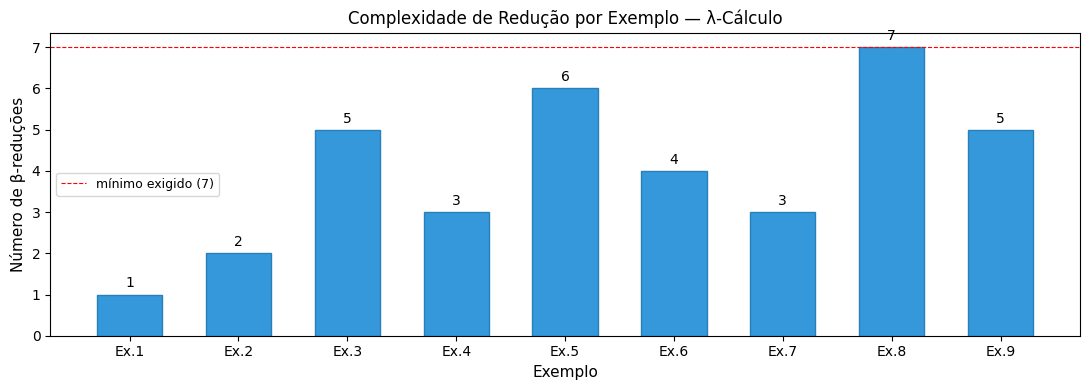

Total de β-reduções nos 9 exemplos com forma normal: 36


In [33]:
# Gráfico: número de β-reduções por exemplo
nomes   = [f'Ex.{i+1}' for i in range(len(casos)-1)]  # exclui Ω
n_passos= []
for src, _, _ in casos[:-1]:
    _, ps = reduce(parse(src), max_steps=100)
    n_passos.append(len(ps) - 1)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(nomes, n_passos, color='#3498db', edgecolor='#2980b9', width=0.6)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel('Exemplo', fontsize=11)
ax.set_ylabel('Número de β-reduções', fontsize=11)
ax.set_title('Complexidade de Redução por Exemplo — λ-Cálculo', fontsize=12)
ax.axhline(7, color='red', linestyle='--', linewidth=0.8, label='mínimo exigido (7)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Total de β-reduções nos 9 exemplos com forma normal: {sum(n_passos)}')

### 5.5 Análise Técnica — λ-Cálculo

| Aspecto | Detalhe |
|---|---|
| **Completude de Turing** | λ-Cálculo é Turing-completo: qualquer função computável pode ser expressa |
| **Estratégia de redução** | Ordem normal (leftmost-outermost) — sempre encontra forma normal se ela existir |
| **Confluência (Church-Rosser)** | A ordem das reduções não afeta a forma normal final (quando existe) |
| **Numerais de Church** | $\bar{n} = \lambda f.\lambda x.f^n(x)$ — adição, multiplicação e potência implementadas |
| **Booleanos de Church** | TRUE = $\lambda tf.t$, FALSE = $\lambda tf.f$ — funcionam como if-then-else |
| **α-renomeação** | Substituição captura-evitante implementada com geração de nomes frescos |
| **Divergência** | $\Omega = (\lambda x.x\ x)(\lambda x.x\ x)$ não possui forma normal — loop infinito |
| **Hipótese Church-Turing** | Qualquer algoritmo é computável no λ-Cálculo se e somente se for computável em uma MT |